# Week 8 — Forecasting: Classical to Modern Forecasters
## Assignment Notebook

**Dataset:** Monthly S&P 500 Index 1990–2024 (downloaded via `yfinance`)

**Instructions:** Every `= None` in a code cell is a value you must compute.
Replace `None` with your expression — do not change the variable name.
All SELF-CHECK assertions must pass before submission.

**Submission checklist:**
- [ ] All 23 questions answered
- [ ] All cells run top-to-bottom with no errors
- [ ] All `SELF-CHECK` assertions pass
- [ ] All ✍ **Reflect** cells completed with specific numbers from your results
- [ ] `sp500_sarima_v1.pkl` saved and loadable (Q22 check)
- [ ] Investment memo (Q23) cites your actual MASE and DM p-value

**Parts:**
1. Data Preparation (Q1–Q5)
2. Classical Models + SARIMA (Q6–Q10)
3. Prophet (Q11–Q12)
4. Feature Engineering + ML (Q13–Q16)
5. Deep Learning (Q17–Q18)
6. Evaluation & Comparison (Q19–Q22)
7. Investment Recommendation (Q23)


## Setup — run these cells before anything else

In [ ]:
# Install all required libraries (run once; restart kernel if prompted)
# !pip install -q yfinance prophet lightgbm xgboost tensorflow statsmodels

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, pickle, os
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools     import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters   import ExponentialSmoothing
from statsmodels.stats.diagnostic  import acorr_ljungbox
from scipy.stats                   import ttest_1samp
from sklearn.model_selection       import TimeSeriesSplit
from sklearn.linear_model          import LinearRegression
from sklearn.preprocessing         import MinMaxScaler
from sklearn.neural_network        import MLPRegressor

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.right': False,
                     'axes.spines.top': False})
print("✅ Imports ready")

Matplotlib is building the font cache; this may take a moment.


✅ Imports ready


In [2]:
# ── Data loading — do NOT modify ──────────────────────────────────────────────
import yfinance as yf
raw = yf.download('^GSPC', start='1990-01-01', end='2024-12-31',
                  interval='1mo', auto_adjust=True, progress=False)
series = raw['Close'].squeeze().rename('SP500')  # closing price
idx = pd.to_datetime(series.index)
idx = idx.tz_convert(None) if idx.tz is not None else idx
series.index = idx.as_unit('ns')
series.index.freq = 'MS'
print(f"✅ yfinance: {len(series)} monthly observations")

TRAIN_END  = '2019-12'
TEST_START = '2020-01'
train     = series[:TRAIN_END]
test      = series[TEST_START:]
log_train = np.log(train)
H         = len(test)
print(f"Train: {len(train)} months  |  Test: {len(test)} months  |  H={H}")

# ── Metric helper — do NOT modify ─────────────────────────────────────────────
def compute_metrics(actual, predicted, train_actual, s=12):
    a = np.array(actual); p = np.array(predicted); e = a - p
    naive_err = np.abs(train_actual.values[s:] - train_actual.values[:-s])
    mae   = np.abs(e).mean()
    rmse  = np.sqrt((e**2).mean())
    mape_ = (np.abs(e / a)).mean() * 100
    smape = (np.abs(e) / ((np.abs(a) + np.abs(p)) / 2)).mean() * 100
    wmae  = (np.abs(e) * a).sum() / a.sum()
    wmape = (np.abs(e / a) * a).sum() / a.sum() * 100
    mase_ = mae / naive_err.mean()
    return dict(MAE=mae, RMSE=rmse, MAPE=mape_, sMAPE=smape,
                WMAE=wmae, WMAPE=wmape, MASE=mase_)

results = {}   # {model_name: np.array of length H}

✅ yfinance: 420 monthly observations
Train: 360 months  |  Test: 60 months  |  H=60


In [4]:
raw.head()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
1990-01-01,329.079987,360.589996,319.829987,353.399994,3793250000
1990-02-01,331.890015,336.089996,322.100006,329.079987,2961970000
1990-03-01,339.940002,344.489990,331.079987,331.890015,3283280000
1990-04-01,330.799988,347.299988,327.760010,339.940002,2801220000
1990-05-01,361.230011,362.260010,330.799988,330.799988,3596680000


In [6]:
series.head()   # Monthly closing prices

Date
1990-01-01    329.079987
1990-02-01    331.890015
1990-03-01    339.940002
1990-04-01    330.799988
1990-05-01    361.230011
Freq: MS, Name: SP500, dtype: float64

---
## Part 1 — Data Preparation (Q1–Q5)


### Q1 — Verify the DatetimeIndex

Before any modelling confirm three things about `series`:
- `index.dtype` is `datetime64[ns]`
- `index.freq` is `'MS'` (Month Start)
- At least 300 monthly observations


In [7]:
# Q1 ──────────────────────────────────────────────────────────────────────────
index_dtype = series.index   # data type of series.index
index_freq  = series.index.freqstr   # standard frequency string from series.index.freqstr
n_obs       = len(series)   # total number of observations in series

print("dtype :", index_dtype)
print("freq  :", index_freq)
print("len   :", n_obs)
print(f"\nTrain: {train.index[0].date()} → {train.index[-1].date()} ({len(train)} months)")
print(f"Test : {test.index[0].date()} → {test.index[-1].date()} ({len(test)} months)")

dtype : DatetimeIndex(['1990-01-01', '1990-02-01', '1990-03-01', '1990-04-01',
               '1990-05-01', '1990-06-01', '1990-07-01', '1990-08-01',
               '1990-09-01', '1990-10-01',
               ...
               '2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01',
               '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', name='Date', length=420, freq='MS')
freq  : MS
len   : 420

Train: 1990-01-01 → 2019-12-01 (360 months)
Test : 2020-01-01 → 2024-12-01 (60 months)


In [8]:
# SELF-CHECK
assert series.index.dtype == 'datetime64[ns]', "Index must be datetime64[ns]"
assert series.index.freqstr == 'MS',           "Frequency must be MS"
assert len(series) >= 300,                     "Expected ≥ 300 observations"
print("✅ Q1 passed")

✅ Q1 passed


✍ **Reflect:** What does `freq='MS'` mean? What would happen to `.shift()` and `.rolling()` operations if the index had no frequency set?
- `freq='MS'` Means frequency is from starting of the Month

### Q2 — Resample to quarterly and annual

Use `.resample().last()` to extract quarterly and annual end-prices.
Then find which decade had the highest mean quarterly log-return.


In [25]:
print("Checking Null values:", log_train.isna().sum())

Checking Null values: 0


In [26]:
train.resample(rule='QE').last().head(), train.resample(rule='YE').last().head()

(Date
 1990-03-31    339.940002
 1990-06-30    358.019989
 1990-09-30    306.049988
 1990-12-31    330.220001
 1991-03-31    375.220001
 Freq: QE-DEC, Name: SP500, dtype: float64,
 Date
 1990-12-31    330.220001
 1991-12-31    417.089996
 1992-12-31    435.709991
 1993-12-31    466.450012
 1994-12-31    459.269989
 Freq: YE-DEC, Name: SP500, dtype: float64)

In [33]:
log_train.resample(rule='QE').last().head()

Date
1990-03-31    5.828769
1990-06-30    5.880589
1990-09-30    5.723748
1990-12-31    5.799759
1991-03-31    5.927513
Freq: QE-DEC, Name: SP500, dtype: float64

Mean quarterly log-return by decade:
 Date
1990    0.0375
2000   -0.0069
2010    0.0266
Name: SP500, dtype: float64


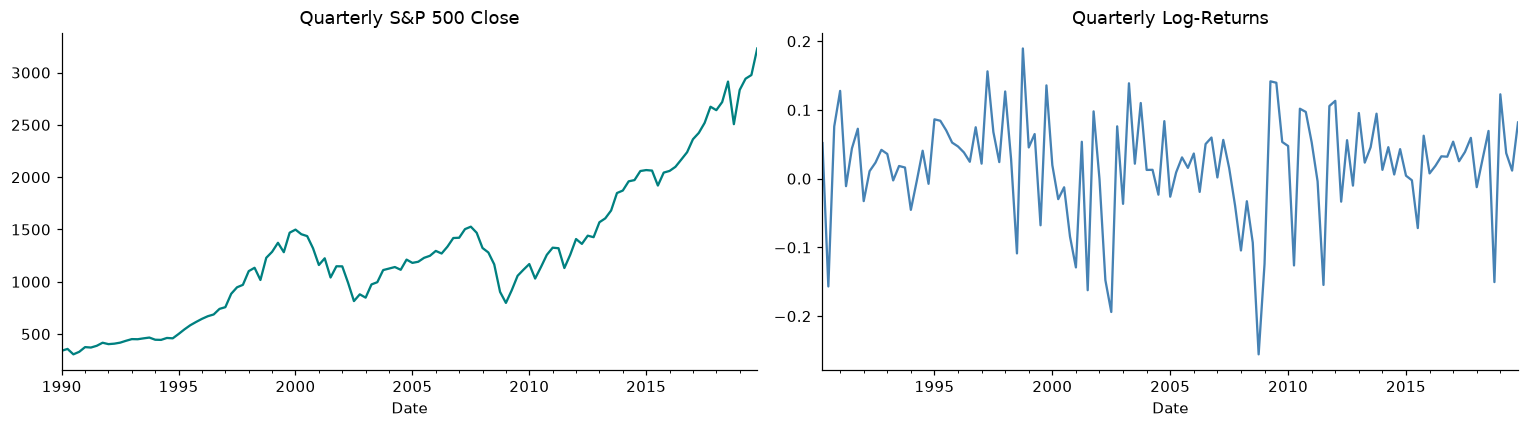

In [61]:
# Q2 ──────────────────────────────────────────────────────────────────────────
quarterly  = train.resample(rule='QE').last()   # quarter-end close prices (QE frequency, last value per quarter)
annual     = train.resample(rule='YE').last()   # year-end close prices (YE frequency, last value per year)
q_log      = log_train.resample(rule='QE').last()   # log-returns of quarterly prices, NaN rows removed
q_log_ret = q_log.diff().dropna()
decade_ret = q_log_ret.groupby((q_log_ret.index.year // 10) * 10).mean()   # mean quarterly log-return grouped by decade (year // 10 * 10)

print("Mean quarterly log-return by decade:\n", decade_ret.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
quarterly.plot(ax=axes[0], title='Quarterly S&P 500 Close', color='teal')
q_log_ret.plot(ax=axes[1], title='Quarterly Log-Returns', color='steelblue')
plt.tight_layout(); plt.show()

 Note: we observed a non-stationary like curve for quaterly closing prices, but when we computed their difference i.e return (log-return in this case), `(New_price - Old_price) / Old_price`, we converted the non-stationary data into stationary like data (not verified yet). We can perform ADF test or other tests to test for stationarity

In [60]:
(q_log_ret.index.year // 10) * 10

Index([1990, 1990, 1990, 1990, 1990, 1990, 1990, 1990, 1990, 1990,
       ...
       2010, 2010, 2010, 2010, 2010, 2010, 2010, 2010, 2010, 2010],
      dtype='int32', name='Date', length=119)

✍ **Reflect:** Why use `.last()` for quarterly price data rather than `.mean()` or `.sum()`? Which decade had the highest and lowest mean quarterly return?
- we use `.last()` for quaterly price data rather than `.mean()` or `.sum()` because it gives the idea about latest state of each quater
- Decade `1990s` had highest mean quaterly log-return of `0.0375` whereas `2000s` had lowest quaterly log-return of `-0.0069`.

### Q3 — Simulate and compare missing-data strategies

Insert `np.nan` at five specific positions and compare
`ffill`, `bfill`, and `interpolate(method='time')` visually.


In [64]:
# Q3 ──────────────────────────────────────────────────────────────────────────
s_gap = series.copy().astype(float)
s_gap.iloc[[10, 50, 120, 200, 310]] = np.nan   # five gaps introduced

In [74]:
s_gap.isna().sum()

np.int64(5)

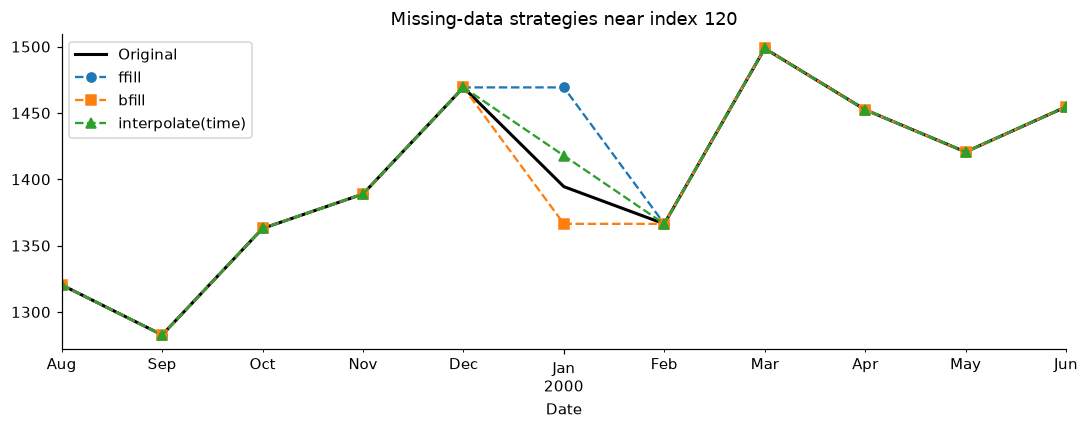

In [76]:
s_ffill  = s_gap.ffill()   # fill each gap with the previous available value
s_bfill  = s_gap.bfill()   # fill each gap with the next available value
s_interp = s_gap.interpolate(method='time')   # fill each gap using time-weighted linear interpolation

w = slice(115, 126)
fig, ax = plt.subplots(figsize=(10, 4))
series.iloc[w].plot(ax=ax, label='Original', lw=2, color='black')
s_ffill.iloc[w].plot(ax=ax,  label='ffill', ls='--', marker='o')
s_bfill.iloc[w].plot(ax=ax,  label='bfill', ls='--', marker='s')
s_interp.iloc[w].plot(ax=ax, label='interpolate(time)', ls='--', marker='^')
ax.set_title('Missing-data strategies near index 120')
ax.legend(); plt.tight_layout(); plt.show()

✍ **Reflect:** For monthly stock prices, which fill strategy is most defensible? Does the choice matter more for small (1-month) or large (6-month) gaps?
- For monthly stock prices, forward fill is generally more defensible than backward fill because it avoids using future information. The effect is minor for short gaps but can become significant for long gaps such as six months, where filling may introduce artificial trends and bias.

### Q4 — Stationarity tests: prices vs log-returns

Run ADF and KPSS on `log_series` and `log_returns`.
- **ADF:** H₀ = unit root (non-stationary). p < 0.05 → reject → stationary
- **KPSS:** H₀ = stationary. p < 0.05 → reject → non-stationary


In [92]:
# Q4 ──────────────────────────────────────────────────────────────────────────
log_series  = log_train.copy()   # natural logarithm of the price series
log_returns = log_train.diff().dropna()   # month-over-month log-return (first difference of log_series, NaN dropped)

def stationarity_report(s, label):
    adf_stat, adf_p, *_ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
    print(f"{label:28s}  ADF p={adf_p:.4f} {'✅ stationary' if adf_p < 0.05 else '❌ unit root'}  "
          f"KPSS p={kpss_p:.4f} {'✅' if kpss_p > 0.05 else '❌ non-stationary'}")

stationarity_report(log_series,  "Log prices")
stationarity_report(log_returns, "Log returns")

Log prices                    ADF p=0.7685 ❌ unit root  KPSS p=0.0100 ❌ non-stationary
Log returns                   ADF p=0.0000 ✅ stationary  KPSS p=0.1000 ✅


C:\Users\NIC\AppData\Local\Temp\ipykernel_7344\1002745461.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
C:\Users\NIC\AppData\Local\Temp\ipykernel_7344\1002745461.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')


Mean log-return: 0.006, , Variance(log_return): 0.002


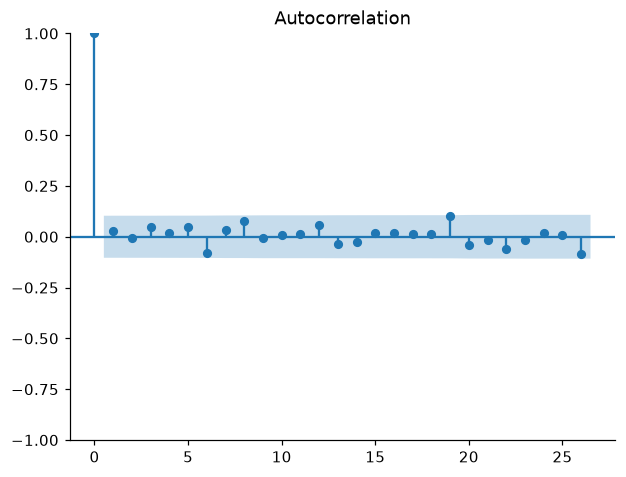

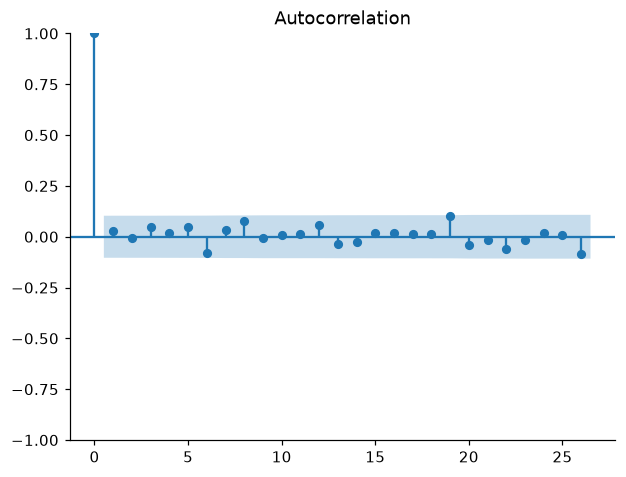

In [99]:
print(f"Mean log-return: {log_returns.mean():.3f}, , Variance(log_return): {log_returns.var():.3f}")
plot_acf(log_returns)

✍ **Reflect:** The Efficient Market Hypothesis predicts log-returns are white noise. Do your ADF/KPSS results support this? What does MASE ≈ 1.0 imply about forecasting on efficient markets?
- Upto the tests we performed and results from ADF/KPSS, log-returns are likely to be white noise. Since `Mean log-return = 0.006` & `Variance of log-return = 0.002`, also the ACF plot supports the answer
- The model has not learned anything useful beyond random guessing / previous value.

### Q5 — ACF / PACF of log-returns

Plot ACF and PACF of `log_returns` with 36 lags.
Based on the plots, propose an ARIMA(p,0,q) order for log-returns.


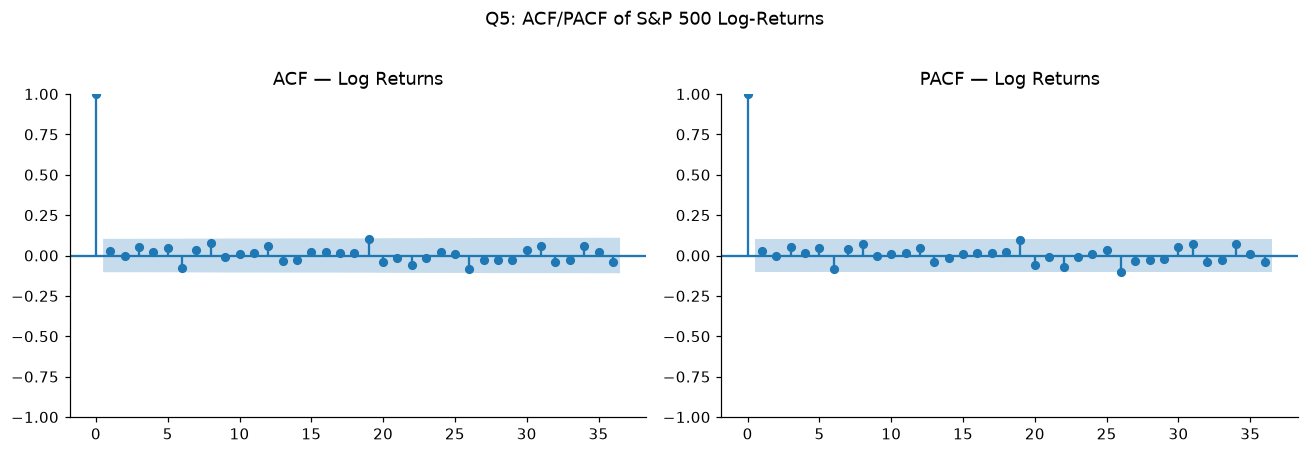

Interpretation: <your answer here>
Proposed ARIMA(p, 0, q): p=?, q=?


In [100]:
# Q5 ──────────────────────────────────────────────────────────────────────────
series_for_acf = log_returns   # series to analyse — log-returns computed in Q4

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf( series_for_acf, lags=36, ax=axes[0], title='ACF — Log Returns')
plot_pacf(series_for_acf, lags=36, ax=axes[1], title='PACF — Log Returns', method='ywm')
plt.suptitle("Q5: ACF/PACF of S&P 500 Log-Returns", y=1.02)
plt.tight_layout(); plt.show()

print("Interpretation: <your answer here>")
print("Proposed ARIMA(p, 0, q): p=?, q=?")

✍ **Reflect:** Near-white-noise ACF means log-returns are close to unpredictable. Does this make forecasting S&P 500 prices worthless? Name one type of strategy that still extracts value from such a series (e.g., volatility forecasting).

---
## Part 2 — Classical Models + SARIMA (Q6–Q10)


### Q6 — Naïve baselines

Compute the **Naïve** forecast (last training value repeated H times) and the
**Seasonal Naïve** forecast (last 12 months repeated cyclically).
Naïve MASE must be ≈ 1.0 by construction — this is the MASE denominator.


In [ ]:
# Q6 ──────────────────────────────────────────────────────────────────────────
naive_fc    = None   # last training observation repeated H times
last_season = None   # final 12 monthly values from the training set, as a numpy array
snaive_fc   = np.tile(last_season, -(-H // 12))[:H]

results['Naive']   = naive_fc
results['S-Naive'] = snaive_fc

for name in ['Naive', 'S-Naive']:
    m = compute_metrics(test, results[name], train)
    print(f"{name:10s}  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

In [ ]:
# SELF-CHECK
naive_mase = compute_metrics(test, results['Naive'], train)['MASE']
assert naive_mase > 0, f"Naive MASE must be positive, got {naive_mase:.4f}"
print(f"✅ Q6 passed — Naive MASE = {naive_mase:.4f}  (all models are measured against this scale)")

✍ **Reflect:** Why is MASE defined using the naïve seasonal error as denominator? Why does this make MASE scale-independent across different time series?

### Q7 — Holt-Winters Exponential Smoothing

Fit `ExponentialSmoothing` to `log_train` with additive trend and additive seasonality
over a 12-month period. Inverse-transform with `np.exp()` before metrics.


In [ ]:
# Q7 ──────────────────────────────────────────────────────────────────────────
hw = ExponentialSmoothing(
    log_train,
    trend=None,              # type of trend component ('add' or 'mul')
    seasonal=None,           # type of seasonal component ('add' or 'mul')
    seasonal_periods=None,   # number of months in one full seasonal cycle
    initialization_method='estimated',
).fit(optimized=True)

print(f"α (level)    = {hw.params['smoothing_level']:.4f}")
print(f"β (trend)    = {hw.params['smoothing_trend']:.4f}")
print(f"γ (seasonal) = {hw.params['smoothing_seasonal']:.4f}")
print(f"AIC = {hw.aic:.2f}   BIC = {hw.bic:.2f}")

hw_log_fc = None                # H-step ahead forecast in log space
results['Holt-Winters'] = None  # inverse log-transform to price space, as numpy array

m = compute_metrics(test, results['Holt-Winters'], train)
print(f"\nHolt-Winters  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

In [ ]:
# SELF-CHECK
hw_mase = compute_metrics(test, results['Holt-Winters'], train)['MASE']
assert hw_mase > 0, f"Holt-Winters MASE must be positive, got {hw_mase:.4f}"
print(f"✅ Q7 passed — Holt-Winters MASE = {hw_mase:.4f}")

✍ **Reflect:** Did γ (seasonal) converge near zero? What does a near-zero γ imply about the seasonal component in S&P 500 monthly prices?

### Q8 — SARIMA order identification

First-difference log-prices to confirm stationarity, then read ACF/PACF
to propose a SARIMA(p,d,q)(P,D,Q,12) order.


In [ ]:
# Q8 ──────────────────────────────────────────────────────────────────────────
diff_log = None   # first difference of log_train with NaN removed

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf( diff_log, ax=axes[0], lags=36, title='ACF — Δlog(S&P500)')
plot_pacf(diff_log, ax=axes[1], lags=36, title='PACF', method='ywm')
plt.tight_layout(); plt.show()

p, d, q = None, None, None   # non-seasonal AR, differencing, MA orders
P, D, Q = None, None, None   # seasonal AR, differencing, MA orders (period = 12)

sarima = SARIMAX(
    log_train,
    order=(p, d, q),
    seasonal_order=(P, D, Q, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

print(f"AIC = {sarima.aic:.2f}   BIC = {sarima.bic:.2f}")
print(sarima.summary().tables[1])

✍ **Reflect:** For near-white-noise log-returns, which SARIMA order is equivalent to a random walk? What does it mean if AutoARIMA selects ARIMA(0,1,0)?

### Q9 — SARIMA residual diagnostics

Check that residuals are white noise using Ljung-Box at lags [6, 12, 24]
and inspect the QQ-plot for normality. If any p-value < 0.05, adjust the order.


In [ ]:
# Q9 ──────────────────────────────────────────────────────────────────────────
residuals = None   # fitted residuals from sarima with NaN removed

lb = acorr_ljungbox(residuals, lags=[6, 12, 24], return_df=True)
print("Ljung-Box (p > 0.05 = white noise at that lag):")
print(lb[['lb_stat', 'lb_pvalue']].round(4))

from scipy import stats as scipy_stats
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
scipy_stats.probplot(residuals, plot=axes[0])
axes[0].set_title('QQ-Plot of SARIMA Residuals')
pd.Series(residuals).plot(ax=axes[1], title='Residuals over time')
axes[1].axhline(0, color='red', lw=0.8)
plt.tight_layout(); plt.show()

failed = (lb['lb_pvalue'] < 0.05).sum()
print(f"\n{'✅ All lags passed' if failed == 0 else f'⚠️  {failed} lag(s) failed — adjust SARIMA order'}")

In [ ]:
# SELF-CHECK
lb_check = acorr_ljungbox(residuals, lags=[6, 12, 24], return_df=True)
failed   = (lb_check['lb_pvalue'] < 0.05).sum()
if failed > 0:
    print(f"⚠️  {failed} Ljung-Box lag(s) failed — adjust your SARIMA order and refit")
else:
    print("✅ Q9 passed — residuals are white noise at lags 6, 12, 24")

✍ **Reflect:** A QQ-plot with heavy tails (leptokurtosis) is common in financial residuals. What does this indicate about the Gaussian noise assumption in ARIMA? Name an alternative distribution for financial returns.

### Q10 — SARIMA forecast with 95% confidence interval

Forecast H steps ahead, inverse-transform with `np.exp()`, and plot the
95% CI. Mark the COVID crash (March 2020) with a vertical dashed line.


In [ ]:
# Q10 ─────────────────────────────────────────────────────────────────────────
fc_obj   = None   # H-step forecast object from sarima
log_mean = None   # point forecast in log space (predicted mean from fc_obj)
log_ci   = None   # confidence interval in log space (alpha=0.05 → 95%)

sarima_fc    = None   # point forecast in price space (inverse log-transform log_mean as numpy array)
sarima_fc_lo = np.exp(log_ci.iloc[:, 0].values)
sarima_fc_hi = np.exp(log_ci.iloc[:, 1].values)

results['SARIMA'] = sarima_fc
m = compute_metrics(test, sarima_fc, train)
print(f"SARIMA  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

fig, ax = plt.subplots(figsize=(13, 5))
train.iloc[-48:].plot(ax=ax, label='Train (last 4y)', color='steelblue', lw=1.5)
test.plot(ax=ax, label='Actual', color='black', lw=1.5)
ax.plot(test.index, sarima_fc, label='SARIMA', color='tomato', lw=2)
ax.fill_between(test.index, sarima_fc_lo, sarima_fc_hi,
                alpha=0.2, color='tomato', label='95% CI')
ax.axvline(pd.Timestamp('2020-03-01'), color='orange', lw=1.5, ls='--', label='COVID crash')
ax.legend(); ax.set_title('SARIMA Forecast vs Actual S&P 500')
plt.tight_layout(); plt.show()

✍ **Reflect:** The 95% CI widens as the horizon increases. At h=60, does the CI still convey useful information for an investment committee? What does an extremely wide CI communicate about uncertainty?

---
## Part 3 — Prophet (Q11–Q12)


### Q11 — Fit Prophet

Prophet requires a DataFrame with columns `ds` (date) and `y` (target).
Fit on `log_train` to keep the scale stable, then `np.exp()` the output.

`changepoint_prior_scale=0.5` allows the trend to flex across financial regimes.


In [ ]:
# Q11 ─────────────────────────────────────────────────────────────────────────
from prophet import Prophet

prophet_df = None   # DataFrame with columns 'ds' = log_train.index and 'y' = log_train.values

m_prop = Prophet(
    seasonality_mode='additive',
    changepoint_prior_scale=0.5,
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
)
m_prop.fit(prophet_df)

future  = m_prop.make_future_dataframe(periods=H, freq='MS')
fc_prop = m_prop.predict(future)
results['Prophet'] = None   # inverse log-transform the last H rows of fc_prop['yhat'] to price space

m = compute_metrics(test, results['Prophet'], train)
print(f"Prophet  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

fig = m_prop.plot_components(fc_prop)
plt.suptitle("Prophet Components", y=1.01); plt.tight_layout(); plt.show()

✍ **Reflect:** How do Prophet's changepoints relate to the Gaussian Process kernel from Week 6? What prior does `changepoint_prior_scale=0.5` place on regime changes — is it more or less flexible than the default?

### Q12 — Prophet cross-validation

`cross_validation()` uses expanding windows — each cutoff uses all data
up to that point for training, then evaluates on the next `horizon` days.


In [ ]:
# Q12 ─────────────────────────────────────────────────────────────────────────
from prophet.diagnostics import cross_validation, performance_metrics

initial_window = None   # minimum training period as a string (10 years ≈ '3650 days')

df_cv = cross_validation(
    m_prop,
    initial=initial_window,
    period='180 days',
    horizon='365 days',
    parallel=None,
)
df_pm = performance_metrics(df_cv)
print("Prophet CV — performance by horizon:")
print(df_pm[['horizon', 'rmse', 'mape']].head())
print(f"\nMean RMSE across horizons: {df_pm['rmse'].mean():.4f}  (log space)")

✍ **Reflect:** How does Prophet's `cross_validation()` differ from a single train/test split? Which gives a more reliable estimate of real-world performance, and why?

---
## Part 4 — Feature Engineering + ML (Q13–Q16)


### Q13 — Implement `make_features()`

Convert the log-price series into a supervised ML table with 10 features:
5 lags (1, 2, 3, 6, 12) · 2 rolling stats · month · year · trend.

**Important:** apply `.shift(1)` before rolling stats to avoid look-ahead leakage.


In [ ]:
# Q13 ─────────────────────────────────────────────────────────────────────────
def make_features(s):
    df = pd.DataFrame({'y': s})

    for lag in [1, 2, 3, 6, 12]:
        df[f'lag_{lag}'] = None   # lag the target column by `lag` positions

    df['roll_12_mean'] = None   # 12-month rolling mean of df['y'].shift(1)
    df['roll_12_std']  = None   # 12-month rolling standard deviation of df['y'].shift(1)

    df['month'] = None   # calendar month (integer 1–12) from the DatetimeIndex
    df['year']  = None   # calendar year from the DatetimeIndex
    df['trend'] = None   # integer sequence 0, 1, 2, …, len(df)−1

    return df.dropna()

FEATURE_COLS  = [c for c in make_features(log_series).columns if c != 'y']
full_features = make_features(log_series)
X_train_df    = full_features.loc[:TRAIN_END, FEATURE_COLS]
y_train_df    = full_features.loc[:TRAIN_END, 'y']
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

In [ ]:
# SELF-CHECK
assert X_train_df.shape[1] == 10, f"Expected 10 features, got {X_train_df.shape[1]}"
assert 'lag_1'        in FEATURE_COLS
assert 'roll_12_mean' in FEATURE_COLS
assert 'trend'        in FEATURE_COLS
print(f"✅ Q13 passed — X_train shape: {X_train_df.shape}")
print(f"   Rows dropped by dropna: {len(log_series) - len(full_features)}")

✍ **Reflect:** How many rows did `dropna()` remove, and why exactly that number? Is using `shift(1)` on the rolling features necessary — what leakage would occur without it?

### Q14 — Walk-forward CV with LinearRegression and XGBoost

Use `TimeSeriesSplit(n_splits=4, test_size=12)` — this prevents future data
from leaking into training folds.


In [ ]:
# Q14 ─────────────────────────────────────────────────────────────────────────
from xgboost import XGBRegressor

tscv = TimeSeriesSplit(n_splits=4, test_size=12)

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_df), 1):
    Xtr  = None   # training features for this fold
    Xval = None   # validation features for this fold
    ytr  = None   # training target for this fold
    yval = None   # validation target for this fold

    lr = LinearRegression()
    lr.fit(Xtr, ytr)
    lr_rmse  = None   # RMSE of LinearRegression predictions on Xval vs yval

    xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                       verbosity=0, random_state=42)
    xgb.fit(Xtr, ytr)
    xgb_rmse = None   # RMSE of XGBoost predictions on Xval vs yval

    print(f"Fold {fold}: {Xval.index[0].date()} → {Xval.index[-1].date()}")
    print(f"  LinReg  RMSE={lr_rmse:.5f}   XGBoost RMSE={xgb_rmse:.5f}")

# Refit on full training set and build recursive forecast (given)
xgb_final = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                         verbosity=0, random_state=42)
xgb_final.fit(X_train_df, y_train_df)
history, xgb_log_fc = list(np.log(series[:TRAIN_END]).values), []
for _ in range(H):
    s_t  = pd.Series(np.exp(history),
                     index=pd.date_range(series.index[0], periods=len(history), freq='MS'))
    row  = make_features(np.log(s_t)).iloc[-1][FEATURE_COLS].values.reshape(1, -1)
    pred = xgb_final.predict(row)[0]
    xgb_log_fc.append(pred); history.append(pred)
results['XGBoost'] = np.exp(xgb_log_fc)
m = compute_metrics(test, results['XGBoost'], train)
print(f"\nXGBoost final  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

✍ **Reflect:** Which fold had the highest RMSE? What was happening in the S&P 500 during that period? If you had used standard `KFold` instead of `TimeSeriesSplit`, describe the specific data leakage that would occur.

### Q15 — LightGBM recursive forecast

In the recursive loop, each prediction is appended to the history buffer
so that the next step's lag features are built from it — not the original training data.


In [ ]:
# Q15 ─────────────────────────────────────────────────────────────────────────
from lightgbm import LGBMRegressor

lgb = LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31,
                    random_state=42, verbose=-1)
lgb.fit(X_train_df, y_train_df)

history    = list(np.log(series[:TRAIN_END]).values)
lgb_log_fc = []
for _ in range(H):
    s_t  = pd.Series(np.exp(history),
                     index=pd.date_range(series.index[0], periods=len(history), freq='MS'))
    row  = make_features(np.log(s_t)).iloc[-1][FEATURE_COLS].values.reshape(1, -1)
    pred = lgb.predict(row)[0]
    lgb_log_fc.append(pred)
    next_val = None   # value to extend history with before the next iteration
    history.append(next_val)

results['LightGBM'] = None   # convert lgb_log_fc from log scale to price scale

m = compute_metrics(test, results['LightGBM'], train)
print(f"LightGBM  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

fi = pd.Series(lgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
fi.plot(kind='barh', figsize=(8, 4), title='LightGBM Feature Importances')
plt.tight_layout(); plt.show()

In [ ]:
# SELF-CHECK
lgb_mase = compute_metrics(test, results['LightGBM'], train)['MASE']
assert lgb_mase > 0, f"LightGBM MASE must be positive, got {lgb_mase:.4f}"
print(f"✅ Q15 passed — LightGBM MASE = {lgb_mase:.4f}")

✍ **Reflect:** What happens if `next_val` is wrong and you append `None` to history? Describe the incorrect behaviour: what would `lag_1` be on step 2?

### Q16 — Quantile regression for prediction intervals

Fit two LightGBM models with `objective='quantile'` at α=0.025 and α=0.975.
Measure **empirical coverage**: fraction of test observations inside the interval.
A well-calibrated 95% PI should cover ≈ 95% of points.


In [ ]:
# Q16 ─────────────────────────────────────────────────────────────────────────
from lightgbm import LGBMRegressor

alpha_lo = None   # lower quantile level for a 95% prediction interval
alpha_hi = None   # upper quantile level for a 95% prediction interval

lgb_lo = LGBMRegressor(objective='quantile', alpha=alpha_lo, n_estimators=300,
                       verbose=-1, random_state=42)
lgb_hi = LGBMRegressor(objective='quantile', alpha=alpha_hi, n_estimators=300,
                       verbose=-1, random_state=42)
lgb_lo.fit(X_train_df, y_train_df)
lgb_hi.fit(X_train_df, y_train_df)

X_test_approx = make_features(log_series).loc[TEST_START:][FEATURE_COLS]
lo_fc = None   # lower-bound price forecasts (predict with lgb_lo, inverse log-transform)
hi_fc = None   # upper-bound price forecasts (predict with lgb_hi, inverse log-transform)

in_interval = None   # boolean array: True where test value is inside [lo_fc, hi_fc]
coverage = in_interval.mean() * 100
print(f"Empirical 95% PI coverage: {coverage:.1f}%  (expected ≈ 95%)")

fig, ax = plt.subplots(figsize=(12, 4))
test.plot(ax=ax, label='Actual', color='black')
pd.Series(results['LightGBM'], index=test.index).plot(
    ax=ax, label='LightGBM point', color='steelblue', ls='--')
ax.fill_between(test.index, lo_fc, hi_fc, alpha=0.3, color='steelblue', label='95% PI')
ax.set_title('LightGBM Quantile Prediction Intervals'); ax.legend()
plt.tight_layout(); plt.show()

✍ **Reflect:** If coverage is 74% instead of 95%, name two possible causes. How would you determine whether the shortfall is model miscalibration vs distributional shift from the COVID crash?

---
## Part 5 — Deep Learning (Q17–Q18)


### Q17 — MLP on lag features

`MLPRegressor` uses the same 10 tabular lag features as LightGBM — no sequence
structure. Use three hidden layers of decreasing width with early stopping.


In [ ]:
# Q17 ─────────────────────────────────────────────────────────────────────────
hidden_sizes = None   # tuple of layer sizes — three layers of decreasing width

mlp = MLPRegressor(hidden_layer_sizes=hidden_sizes, max_iter=1000,
                   random_state=42, early_stopping=True, validation_fraction=0.1)
mlp.fit(X_train_df, y_train_df)

history    = list(np.log(series[:TRAIN_END]).values)
mlp_log_fc = []
for _ in range(H):
    s_t  = pd.Series(np.exp(history),
                     index=pd.date_range(series.index[0], periods=len(history), freq='MS'))
    row  = make_features(np.log(s_t)).iloc[-1][FEATURE_COLS].values.reshape(1, -1)
    pred = mlp.predict(row)[0]
    mlp_log_fc.append(pred); history.append(pred)

results['MLP'] = None   # convert mlp_log_fc from log scale to price scale
m = compute_metrics(test, results['MLP'], train)
print(f"MLP  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

✍ **Reflect:** Compare MLP MASE vs LinearRegression MASE from Q14. Did the non-linearity help? Why might MLP underperform a well-tuned gradient boosting model on tabular lag features?

### Q18 — Keras LSTM

LSTM takes a 3D input: `(samples, LOOKBACK=12, 1)`. Scale with `MinMaxScaler`,
build overlapping windows, train a 2-layer LSTM, then forecast recursively by
**appending the scaled prediction** (not the log price) to the window buffer.


In [ ]:
# Q18 ─────────────────────────────────────────────────────────────────────────
import tensorflow as tf
tf.random.set_seed(42)

LOOKBACK     = 12
scaler_lstm  = MinMaxScaler()
log_train_sc = scaler_lstm.fit_transform(log_train.values.reshape(-1, 1)).flatten()

X_seq, y_seq = [], []
for i in range(LOOKBACK, len(log_train_sc)):
    X_seq.append(log_train_sc[i-LOOKBACK:i])
    y_seq.append(log_train_sc[i])

X_3d  = None   # convert X_seq to numpy array shaped (samples, LOOKBACK, 1)
y_arr = np.array(y_seq)

units_1 = None   # number of units in the first LSTM layer
units_2 = None   # number of units in the second LSTM layer

lstm_model = tf.keras.Sequential([
    tf.keras.layers.LSTM(units_1, return_sequences=True, input_shape=(LOOKBACK, 1)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(units_2),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1),
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_3d, y_arr, epochs=50, batch_size=16, verbose=0,
               validation_split=0.1,
               callbacks=[tf.keras.callbacks.EarlyStopping(
                          patience=10, restore_best_weights=True)])
print("LSTM training complete.")

window         = list(log_train_sc[-LOOKBACK:])
lstm_log_fc_sc = []
for _ in range(H):
    x_in    = np.array(window[-LOOKBACK:]).reshape(1, LOOKBACK, 1)
    pred_sc = lstm_model.predict(x_in, verbose=0)[0, 0]
    lstm_log_fc_sc.append(pred_sc)
    next_window = None   # scaled value to add to window — use pred_sc, not the log price
    window.append(next_window)

lstm_log_fc    = scaler_lstm.inverse_transform(
    np.array(lstm_log_fc_sc).reshape(-1, 1)).flatten()
results['LSTM'] = None   # convert lstm_log_fc from log scale to price scale
m = compute_metrics(test, results['LSTM'], train)
print(f"LSTM  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

✍ **Reflect:** Compare LSTM MASE vs SARIMA MASE. Was the added complexity worth it on this dataset? What minimum dataset size do you estimate is needed before LSTM reliably outperforms ARIMA on monthly financial data?

---
## Part 6 — Evaluation & Comparison (Q19–Q22)


### Q19 — Full metrics table

Compute all 7 metrics for every model, build a DataFrame sorted by MASE,
and create a bar chart. A model with MASE > 1.0 is worse than the naïve baseline.


In [ ]:
# Q19 ─────────────────────────────────────────────────────────────────────────
metric_rows = {}
for name, fc in results.items():
    if len(np.array(fc)) == H:
        row = None   # compute all 7 metrics for this model's forecast
        metric_rows[name] = row

metrics_df = None   # DataFrame from metric_rows, transposed, rounded to 4 places, sorted by MASE

print("=== Model Comparison (sorted by MASE) ===")
print(metrics_df.to_string())

metrics_df['MASE'].plot(
    kind='bar', figsize=(10, 4),
    color=['tomato' if v > 1.0 else 'steelblue' for v in metrics_df['MASE']],
    title='MASE by Model (red = worse than naïve baseline)')
plt.axhline(1.0, color='red', ls='--', label='Naïve = 1.0')
plt.ylabel('MASE'); plt.xticks(rotation=45, ha='right')
plt.legend(); plt.tight_layout(); plt.show()

✍ **Reflect:** Which model ranks differently on WMAPE vs MAPE? Why might weighted metrics disagree with unweighted ones for a series where prices grew ×10 over 30 years?

### Q20 — Error by calendar month

Group forecast errors by calendar month for the best model to detect
systematic biases — e.g., does the model consistently over-predict in March?


In [ ]:
# Q20 ─────────────────────────────────────────────────────────────────────────
best_name = metrics_df.index[0]
best_fc   = np.array(results[best_name])

errors       = None   # actual test values minus best_fc (residuals in price space)
err_df       = pd.DataFrame({'error': errors}, index=test.index)
monthly_bias = None   # mean error grouped by calendar month (integer 1–12)

fig, ax = plt.subplots(figsize=(10, 4))
monthly_bias.plot(kind='bar', ax=ax,
                  color=['tomato' if v < 0 else 'steelblue' for v in monthly_bias])
ax.axhline(0, color='black', lw=0.8)
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title(f'{best_name} — Mean Error by Calendar Month')
ax.set_ylabel('Mean error (actual − predicted, S&P pts)')
plt.tight_layout(); plt.show()
print(f"Largest negative bias: month {monthly_bias.idxmin()}")

✍ **Reflect:** Does March show up as an outlier? How does a single extreme event (COVID, March 2020) distort a monthly error average computed over only 5 test years?

### Q21 — Error by forecast horizon

Plot MAE at each step h = 1..H for the two best models.
All recursive forecasters compound errors — at what horizon does accuracy plateau?


In [ ]:
# Q21 ─────────────────────────────────────────────────────────────────────────
top2 = list(metrics_df.index[:2])

fig, ax = plt.subplots(figsize=(12, 5))
for name in top2:
    fc       = np.array(results[name])
    mae_by_h = [abs(test.values[h] - fc[h]) for h in range(H)]
    ax.plot(range(1, H+1), mae_by_h, label=name)

h_1yr = None   # horizon value for the 1-year mark (in months)
h_2yr = None   # horizon value for the 2-year mark (in months)
ax.axvline(h_1yr, color='grey', lw=1, ls='--', label='h=12 (1 yr)')
ax.axvline(h_2yr, color='grey', lw=1, ls=':',  label='h=24 (2 yr)')
ax.set_xlabel('Forecast horizon (months ahead)')
ax.set_ylabel('Absolute error (S&P points)')
ax.set_title('Accuracy Degradation by Horizon')
ax.legend(); plt.tight_layout(); plt.show()

✍ **Reflect:** At what horizon do both models converge to roughly the same error? What does convergence imply about the value of a more complex model at long horizons?

### Q22 — Ensemble + Diebold-Mariano test + save model

Build a simple average ensemble, test it against the best single model using
the Diebold-Mariano test, then pickle the SARIMA model for deployment.

**DM test:** H₀ = equal predictive accuracy. p > 0.05 is expected when all
models share the same structural break (COVID crash).


In [ ]:
# Q22 ─────────────────────────────────────────────────────────────────────────
top4        = list(metrics_df.index[:4])
ensemble_fc = None   # element-wise average of the top-4 model forecasts

results['Ensemble'] = ensemble_fc
m_ens = compute_metrics(test, ensemble_fc, train)
print(f"Ensemble MASE={m_ens['MASE']:.4f}  RMSE={m_ens['RMSE']:.1f}")
print(f"Component models: {top4}")

e1 = (test.values - np.array(results[best_name])) ** 2
e2 = (test.values - ensemble_fc) ** 2
d  = None   # loss differential: squared error of best single model minus squared error of ensemble

dm_stat, dm_p = ttest_1samp(d, 0)
print(f"\nDiebold-Mariano  stat={dm_stat:.4f}  p={dm_p:.4f}")
print("p > 0.05 → cannot reject equal accuracy" if dm_p >= 0.05
      else "p < 0.05 → ensemble is significantly more accurate")

with open('../assignment/sp500_sarima_v1.pkl', 'wb') as f:
    pickle.dump(sarima, f)
print("✅ SARIMA model saved to sp500_sarima_v1.pkl")

In [ ]:
# SELF-CHECK
assert os.path.exists('../assignment/sp500_sarima_v1.pkl'), "Model file not found"
with open('../assignment/sp500_sarima_v1.pkl', 'rb') as f:
    loaded = pickle.load(f)
print("✅ Q22 passed — model saved and loadable")

✍ **Reflect:** DM p > 0.05 means the improvement could be random noise. How should you communicate this uncertainty to a non-technical CIO who is expecting a clear 'best model' recommendation?

---
## Part 7 — Investment Recommendation (Q23)


### Q23 — 200-Word Investment Memo

Write a memo to the CIO. Replace every `[...]` with specific numbers from
your results. The memo must cite your actual MASE values and DM p-value.

---

**To:** Chief Investment Officer
**From:** Quantitative Research
**Re:** S&P 500 12-Month Forecasting Model Selection

**Recommendation:** Deploy the **[MODEL NAME]** model for monthly equity allocation targets.

**Accuracy:** On the 2020–2024 test period (60 months), [MODEL] achieved MASE = [X.XX]
vs the random-walk baseline (MASE = 1.00). Other models: [list 2–3 with their MASE].
The improvement over the naïve baseline was [statistically significant / not significant]
(Diebold-Mariano p = [X.XX]).

**Structural break risk:** All models failed to anticipate the March 2020 COVID crash
(actual −34%; [MODEL] forecast [+/−X%]). We recommend reporting 95% prediction intervals
(empirical coverage = [X]% in back-test) rather than point forecasts alone.

**Non-accuracy criteria:**
1. **Interpretability:** [MODEL] [is / is not] interpretable to investment committee.
2. **Regulatory:** [How the model can be explained to regulators — 1 sentence].
3. **Operational:** Refit latency is approximately [X seconds/minutes] monthly.

**Conclusion:** [One sentence acknowledging EMH constraints and recommending the model].

---


In [ ]:
# Q23 — reference numbers (run to look up your values)
print(f"Best model    : {metrics_df.index[0]}")
print(f"Best MASE     : {metrics_df['MASE'].iloc[0]:.4f}")
print(f"Naive MASE    : {metrics_df.loc['Naive', 'MASE']:.4f}")
print(f"Ensemble MASE : {m_ens['MASE']:.4f}")
print(f"\nAll models (MASE):")
print(metrics_df['MASE'].round(4).to_string())
print(f"\nDM test: stat={dm_stat:.4f}  p={dm_p:.4f}")